# MFCC Feature Importance and Correlation Analysis

This notebook creates two types of evidence for the report. First, it computes validation-only permutation importance for the saved 80-dimensional aggregated MFCC SVM pipeline. Second, it saves a training-split correlation matrix to inspect univariate feature-target relationships and possible redundancy among MFCC summary features. It does not train a new model and does not use the test split for feature ranking.


### Setup


In [1]:
# Check that the required packages are available. Install only missing packages.
import importlib.util
import subprocess
import sys

required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("joblib", "joblib"),
]

missing = [pip_name for import_name, pip_name in required_packages if importlib.util.find_spec(import_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Required packages are already installed.")


Required packages are already installed.


In [2]:
# Imports and fixed parameters.
import json
import os
import random
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, make_scorer, precision_score, recall_score

try:
    from IPython.display import display
except Exception:
    display = print

RANDOM_STATE = 42
N_REPEATS = int(os.environ.get("FEATURE_IMPORTANCE_N_REPEATS", "5"))
N_JOBS = int(os.environ.get("FEATURE_IMPORTANCE_N_JOBS", "-1"))
CLASS_NAMES = {0: "bona_fide", 1: "synthetic"}
POSITIVE_CLASS = "synthetic"
CORRELATION_THRESHOLD = 0.90

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid")


In [3]:
# Mount Google Drive when running in Colab. This is skipped outside Colab.
from pathlib import Path


def mount_google_drive_if_colab(mount_point="/content/drive"):
    try:
        import google.colab  # noqa: F401
        from google.colab import drive
    except Exception:
        print("Google Drive mount skipped: not running in Colab.")
        return False

    mount_path = Path(mount_point)
    if mount_path.exists() and any(mount_path.iterdir()):
        print(f"Google Drive already available at {mount_point}.")
        return True

    drive.mount(mount_point)
    print(f"Google Drive mounted at {mount_point}.")
    return True


RUNNING_WITH_GOOGLE_DRIVE = mount_google_drive_if_colab()


Mounted at /content/drive
Google Drive mounted at /content/drive.


Class and Function Declaration

In [ ]:
# Resolve repository and output paths across local Windows and Google Drive layouts.
def output_root_has_required_artifacts(output_root):
    output_root = Path(output_root)
    return (
        (output_root / "svm" / "cache" / "X_train.npy").exists()
        and (output_root / "svm" / "cache" / "y_train.npy").exists()
        and (output_root / "svm" / "cache" / "X_validation.npy").exists()
        and (output_root / "svm" / "cache" / "y_validation.npy").exists()
        and (output_root / "svm" / "models" / "svm_c_trial_best_validation_model.joblib").exists()
    )


def find_outputs_root(project_root):
    explicit = os.environ.get("INTRO_AI_OUTPUTS_ROOT")
    candidates = []
    if explicit:
        candidates.append(Path(explicit).expanduser())

    project_root = Path(project_root).expanduser()
    candidates.extend([
        project_root / "outputs" / "outputs",
        project_root / "outputs",
        project_root,
    ])

    for candidate in candidates:
        candidate = candidate.resolve() if candidate.exists() else candidate
        if output_root_has_required_artifacts(candidate):
            return candidate

    checked = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(
        "Could not find SVM cache/model artifacts under the expected output roots. "
        "Set INTRO_AI_OUTPUTS_ROOT to the folder that contains the svm folder. Checked:\n" + checked
    )


def resolve_project_root():
    explicit = os.environ.get("INTRO_AI_PROJECT_ROOT")
    candidates = []
    if explicit:
        candidates.append(Path(explicit).expanduser())

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])

    drive_roots = [
        Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701"),
        Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701/Intro-to-AI"),
        Path("/content/drive/MyDrive/INM701"),
        Path("/content/drive/MyDrive/Intro-to-AI"),
    ]
    candidates.extend(drive_roots)

    windows_fallback = Path("C:/Users/PC/Documents/GitHub/Intro-to-AI")
    candidates.append(windows_fallback)

    for candidate in candidates:
        if not candidate.exists():
            continue
        try:
            find_outputs_root(candidate)
            return candidate.resolve()
        except FileNotFoundError:
            continue

    checked = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(
        "Could not resolve the Intro-to-AI project root. In Colab, confirm Drive is mounted and that "
        "the INM701 folder contains outputs/svm or outputs/outputs/svm. If your layout differs, set "
        "INTRO_AI_PROJECT_ROOT and INTRO_AI_OUTPUTS_ROOT. Checked:\n" + checked
    )

In [ ]:
PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = find_outputs_root(PROJECT_ROOT)
SVM_ROOT = OUTPUTS_ROOT / "svm"
CACHE_DIR = SVM_ROOT / "cache"
MODEL_DIR = SVM_ROOT / "models"
SVM_TABLE_DIR = SVM_ROOT / "tables"

FEATURE_IMPORTANCE_DIR = OUTPUTS_ROOT / "feature_importance"
TABLES_DIR = FEATURE_IMPORTANCE_DIR / "tables"
FIGURES_DIR = FEATURE_IMPORTANCE_DIR / "figures"
METRICS_DIR = FEATURE_IMPORTANCE_DIR / "metrics"

for directory in [TABLES_DIR, FIGURES_DIR, METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_VARIANT = "rbf_C10_balanced"
MODEL_ARTIFACT = MODEL_DIR / "svm_c_trial_best_validation_model.joblib"

paths = pd.DataFrame([
    {"artifact": "project_root", "path": str(PROJECT_ROOT), "exists": PROJECT_ROOT.exists()},
    {"artifact": "outputs_root", "path": str(OUTPUTS_ROOT), "exists": OUTPUTS_ROOT.exists()},
    {"artifact": "train_features", "path": str(CACHE_DIR / "X_train.npy"), "exists": (CACHE_DIR / "X_train.npy").exists()},
    {"artifact": "train_labels", "path": str(CACHE_DIR / "y_train.npy"), "exists": (CACHE_DIR / "y_train.npy").exists()},
    {"artifact": "validation_features", "path": str(CACHE_DIR / "X_validation.npy"), "exists": (CACHE_DIR / "X_validation.npy").exists()},
    {"artifact": "validation_labels", "path": str(CACHE_DIR / "y_validation.npy"), "exists": (CACHE_DIR / "y_validation.npy").exists()},
    {"artifact": "validation_metadata", "path": str(CACHE_DIR / "validation_metadata.csv"), "exists": (CACHE_DIR / "validation_metadata.csv").exists()},
    {"artifact": "feature_config", "path": str(CACHE_DIR / "feature_config.json"), "exists": (CACHE_DIR / "feature_config.json").exists()},
    {"artifact": "selected_svm_model", "path": str(MODEL_ARTIFACT), "exists": MODEL_ARTIFACT.exists()},
    {"artifact": "svm_c_trial_table", "path": str(SVM_TABLE_DIR / "svm_c_trial.csv"), "exists": (SVM_TABLE_DIR / "svm_c_trial.csv").exists()},
])
display(paths)

if not paths["exists"].all():
    missing = paths.loc[~paths["exists"], "path"].tolist()
    raise FileNotFoundError("Missing required artifacts: " + "; ".join(missing))


,artifact,path,exists
0,project_root,/content/drive/MyDrive/Colab Notebooks/Educati...,True
1,outputs_root,/content/drive/MyDrive/Colab Notebooks/Educati...,True
2,train_features,/content/drive/MyDrive/Colab Notebooks/Educati...,True
3,train_labels,/content/drive/MyDrive/Colab Notebooks/Educati...,True
4,validation_features,/content/drive/MyDrive/Colab Notebooks/Educati...,True
5,validation_labels,/content/drive/MyDrive/Colab Notebooks/Educati...,True
6,validation_metadata,/content/drive/MyDrive/Colab Notebooks/Educati...,True
7,feature_config,/content/drive/MyDrive/Colab Notebooks/Educati...,True
8,selected_svm_model,/content/drive/MyDrive/Colab Notebooks/Educati...,True
9,svm_c_trial_table,/content/drive/MyDrive/Colab Notebooks/Educati...,True


### Data


In [ ]:


# Load cached training and validation data. Do not load the test split in this notebook.
with open(CACHE_DIR / "feature_config.json", "r", encoding="utf-8") as handle:
    feature_config = json.load(handle)

X_train = np.load(CACHE_DIR / "X_train.npy")
y_train = np.load(CACHE_DIR / "y_train.npy")
X_validation = np.load(CACHE_DIR / "X_validation.npy")
y_validation = np.load(CACHE_DIR / "y_validation.npy")
validation_metadata = pd.read_csv(CACHE_DIR / "validation_metadata.csv")

feature_names = [f"mfcc_{idx:02d}_mean" for idx in range(1, 41)] + [f"mfcc_{idx:02d}_std" for idx in range(1, 41)]

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("validation", X_validation, y_validation),
]:
    if X_split.ndim != 2:
        raise ValueError(f"Expected a 2-D {split_name} feature matrix, got shape {X_split.shape}")
    if X_split.shape[1] != len(feature_names):
        raise ValueError(f"Expected 80 {split_name} features, got {X_split.shape[1]}")
    if len(y_split) != X_split.shape[0]:
        raise ValueError(f"{split_name} feature and label counts do not match.")

summary_rows = [
    {"check": "permutation_importance_split", "value": "validation"},
    {"check": "correlation_matrix_split", "value": "training"},
    {"check": "training_rows", "value": int(X_train.shape[0])},
    {"check": "validation_rows", "value": int(X_validation.shape[0])},
    {"check": "feature_count", "value": int(X_validation.shape[1])},
    {"check": "feature_representation", "value": feature_config.get("representation")},
    {"check": "scaling", "value": "cached SVM features loaded directly; scaler not refitted or reapplied"},
    {"check": "label_mapping", "value": str(CLASS_NAMES)},
    {"check": "test_set_used_for_feature_ranking", "value": False},
]
display(pd.DataFrame(summary_rows))


,check,value
0,permutation_importance_split,validation
1,correlation_matrix_split,training
2,training_rows,9060
3,validation_rows,1942
4,feature_count,80
5,feature_representation,"aggregated MFCC mean+std (80 features), Standa..."
6,scaling,cached SVM features loaded directly; scaler no...
7,label_mapping,"{0: 'bona_fide', 1: 'synthetic'}"
8,test_set_used_for_feature_ranking,False


### Correlation Matrix


In [6]:
# Compute training-split correlations between MFCC features and the target.
train_feature_df = pd.DataFrame(X_train, columns=feature_names)
train_feature_df["target_synthetic"] = y_train.astype(int)

correlation_matrix = train_feature_df.corr(method="pearson")
feature_target_correlations = (
    correlation_matrix["target_synthetic"]
    .drop(labels=["target_synthetic"])
    .rename("pearson_correlation_with_target")
    .reset_index()
    .rename(columns={"index": "feature_name"})
)
feature_target_correlations["abs_pearson_correlation_with_target"] = feature_target_correlations["pearson_correlation_with_target"].abs()
feature_target_correlations["mfcc_number"] = [idx for idx in range(1, 41)] + [idx for idx in range(1, 41)]
feature_target_correlations["aggregation"] = ["mean"] * 40 + ["std"] * 40
feature_target_correlations = feature_target_correlations.sort_values(
    "abs_pearson_correlation_with_target", ascending=False
).reset_index(drop=True)
feature_target_correlations.insert(0, "rank_by_abs_target_correlation", np.arange(1, len(feature_target_correlations) + 1))

feature_only_corr = correlation_matrix.loc[feature_names, feature_names]
upper_mask = np.triu(np.ones(feature_only_corr.shape, dtype=bool), k=1)
high_corr_pairs = (
    feature_only_corr.where(upper_mask)
    .stack()
    .rename("pearson_correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
)
high_corr_pairs["abs_pearson_correlation"] = high_corr_pairs["pearson_correlation"].abs()
high_corr_pairs = high_corr_pairs[
    high_corr_pairs["abs_pearson_correlation"] >= CORRELATION_THRESHOLD
].sort_values("abs_pearson_correlation", ascending=False).reset_index(drop=True)

print(f"Highly correlated feature pairs at abs(r) >= {CORRELATION_THRESHOLD}: {len(high_corr_pairs)}")
display(feature_target_correlations.head(20))


Highly correlated feature pairs at abs(r) >= 0.9: 15


,rank_by_abs_target_correlation,feature_name,pearson_correlation_with_target,abs_pearson_correlation_with_target,mfcc_number,aggregation
0,1,mfcc_03_mean,0.389185,0.389185,3,mean
1,2,mfcc_05_mean,0.343545,0.343545,5,mean
2,3,mfcc_24_mean,-0.338961,0.338961,24,mean
3,4,mfcc_17_mean,-0.335707,0.335707,17,mean
4,5,mfcc_35_mean,-0.332062,0.332062,35,mean
5,6,mfcc_15_mean,-0.317124,0.317124,15,mean
6,7,mfcc_26_mean,-0.306453,0.306453,26,mean
7,8,mfcc_33_mean,-0.290630,0.290630,33,mean
8,9,mfcc_16_mean,0.281094,0.281094,16,mean
9,10,mfcc_12_mean,0.252147,0.252147,12,mean


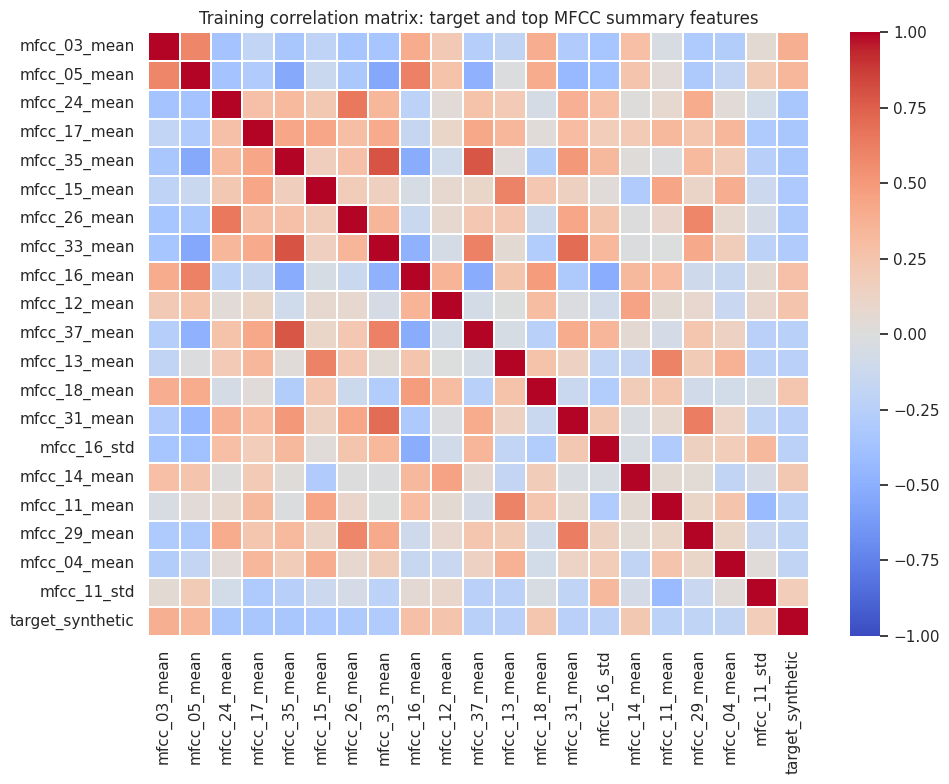

Saved full feature-target correlation matrix: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/feature_importance/tables/feature_target_correlation_matrix_train.csv
Saved ranked target correlations: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/feature_importance/tables/feature_target_correlations_train.csv
Saved highly correlated feature pairs: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/feature_importance/tables/high_correlation_pairs_train.csv
Saved top-feature correlation heatmap: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/feature_importance/figures/correlation_matrix_top20_train.png


In [7]:
# Save correlation tables and a readable heatmap for the target plus the top 20 target-correlated features.
correlation_matrix_path = TABLES_DIR / "feature_target_correlation_matrix_train.csv"
target_correlations_path = TABLES_DIR / "feature_target_correlations_train.csv"
high_corr_pairs_path = TABLES_DIR / "high_correlation_pairs_train.csv"
correlation_figure_path = FIGURES_DIR / "correlation_matrix_top20_train.png"

top_correlation_features = feature_target_correlations.head(20)["feature_name"].tolist()
readable_corr = correlation_matrix.loc[top_correlation_features + ["target_synthetic"], top_correlation_features + ["target_synthetic"]]

correlation_matrix.to_csv(correlation_matrix_path)
feature_target_correlations.to_csv(target_correlations_path, index=False)
high_corr_pairs.to_csv(high_corr_pairs_path, index=False)

plt.figure(figsize=(10, 8))
sns.heatmap(readable_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.2)
plt.title("Training correlation matrix: target and top MFCC summary features")
plt.tight_layout()
plt.savefig(correlation_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved full feature-target correlation matrix:", correlation_matrix_path)
print("Saved ranked target correlations:", target_correlations_path)
print("Saved highly correlated feature pairs:", high_corr_pairs_path)
print("Saved top-feature correlation heatmap:", correlation_figure_path)


### Permutation Importance


In [8]:
# Load the saved SVM validation-selected C=10 model. No model fitting is performed here.
model = joblib.load(MODEL_ARTIFACT)

baseline_predictions = model.predict(X_validation)
baseline_metrics = {
    "accuracy": accuracy_score(y_validation, baseline_predictions),
    "precision": precision_score(y_validation, baseline_predictions, zero_division=0),
    "recall": recall_score(y_validation, baseline_predictions, zero_division=0),
    "f1": f1_score(y_validation, baseline_predictions, zero_division=0),
}

display(pd.DataFrame([{
    "model": "SVM",
    "variant": MODEL_VARIANT,
    "split": "validation",
    **baseline_metrics,
}]))
print("Loaded model:", MODEL_ARTIFACT)
print("Model object:", model)


,model,variant,split,accuracy,precision,recall,f1
0,SVM,rbf_C10_balanced,validation,0.968589,0.984871,0.969471,0.977111


Loaded model: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/models/svm_c_trial_best_validation_model.joblib
Model object: SVC(C=10.0, class_weight='balanced', random_state=42)


In [9]:
# Compute validation-only permutation importance with binary F1 for the synthetic class.
start_time = time.time()
scorer = make_scorer(f1_score, zero_division=0)

permutation_result = permutation_importance(
    model,
    X_validation,
    y_validation,
    scoring=scorer,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

runtime_seconds = time.time() - start_time
importance_df = pd.DataFrame({
    "feature_index": np.arange(len(feature_names)),
    "feature_name": feature_names,
    "mfcc_number": [idx for idx in range(1, 41)] + [idx for idx in range(1, 41)],
    "aggregation": ["mean"] * 40 + ["std"] * 40,
    "mean_f1_drop": permutation_result.importances_mean,
    "std_f1_drop": permutation_result.importances_std,
    "min_f1_drop": permutation_result.importances.min(axis=1),
    "max_f1_drop": permutation_result.importances.max(axis=1),
    "mean_permuted_f1": baseline_metrics["f1"] - permutation_result.importances_mean,
})

for repeat_idx in range(N_REPEATS):
    importance_df[f"f1_drop_repeat_{repeat_idx + 1:02d}"] = permutation_result.importances[:, repeat_idx]

importance_df = importance_df.sort_values("mean_f1_drop", ascending=False).reset_index(drop=True)
importance_df.insert(0, "rank", np.arange(1, len(importance_df) + 1))

top20_df = importance_df.head(20).copy()
print(f"Permutation importance completed in {runtime_seconds:.1f} seconds.")
display(top20_df[["rank", "feature_name", "aggregation", "mfcc_number", "mean_f1_drop", "std_f1_drop", "mean_permuted_f1"]])


Permutation importance completed in 18.7 seconds.


,rank,feature_name,aggregation,mfcc_number,mean_f1_drop,std_f1_drop,mean_permuted_f1
0,1,mfcc_11_mean,mean,11,0.037831,0.003377,0.939280
1,2,mfcc_12_mean,mean,12,0.036408,0.003153,0.940703
2,3,mfcc_35_mean,mean,35,0.034180,0.001301,0.942931
3,4,mfcc_14_mean,mean,14,0.032393,0.002180,0.944718
4,5,mfcc_08_mean,mean,8,0.031007,0.002817,0.946103
5,6,mfcc_10_mean,mean,10,0.027850,0.002488,0.949260
6,7,mfcc_13_mean,mean,13,0.026675,0.002689,0.950436
7,8,mfcc_32_mean,mean,32,0.024451,0.002991,0.952659
8,9,mfcc_31_mean,mean,31,0.021221,0.003464,0.955890
9,10,mfcc_15_mean,mean,15,0.019517,0.002443,0.957593


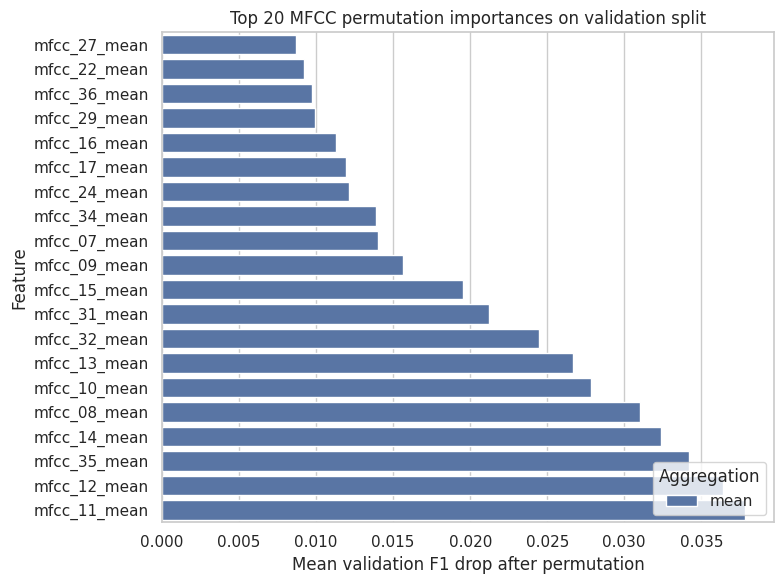

Saved full permutation table: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/feature_importance/tables/permutation_importance_validation.csv
Saved top-20 permutation table: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/feature_importance/tables/permutation_importance_top20.csv
Saved permutation figure: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/feature_importance/figures/permutation_importance_top20.png
Saved summary: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/feature_importance/metrics/feature_importance_summary.json


In [10]:
# Save permutation-importance tables, figure and machine-readable summary.
validation_table_path = TABLES_DIR / "permutation_importance_validation.csv"
top20_table_path = TABLES_DIR / "permutation_importance_top20.csv"
figure_path = FIGURES_DIR / "permutation_importance_top20.png"
summary_path = METRICS_DIR / "feature_importance_summary.json"

importance_df.to_csv(validation_table_path, index=False)
top20_df.to_csv(top20_table_path, index=False)

plot_df = top20_df.sort_values("mean_f1_drop", ascending=True)
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x="mean_f1_drop", y="feature_name", hue="aggregation", dodge=False)
plt.xlabel("Mean validation F1 drop after permutation")
plt.ylabel("Feature")
plt.title("Top 20 MFCC permutation importances on validation split")
plt.legend(title="Aggregation", loc="lower right")
plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

summary = {
    "model_used": "SVM",
    "model_variant": MODEL_VARIANT,
    "model_artifact": str(MODEL_ARTIFACT.relative_to(PROJECT_ROOT)),
    "permutation_importance_split_used": "validation",
    "correlation_matrix_split_used": "training",
    "metric_used": "binary F1-score for synthetic class",
    "n_repeats": int(N_REPEATS),
    "random_state": int(RANDOM_STATE),
    "baseline_validation_accuracy": float(baseline_metrics["accuracy"]),
    "baseline_validation_precision": float(baseline_metrics["precision"]),
    "baseline_validation_recall": float(baseline_metrics["recall"]),
    "baseline_validation_f1": float(baseline_metrics["f1"]),
    "number_of_features_tested": int(len(feature_names)),
    "feature_representation": feature_config.get("representation"),
    "cached_features_used_directly": True,
    "scaler_refitted_or_reapplied": False,
    "test_set_used_for_feature_ranking": False,
    "runtime_seconds": float(runtime_seconds),
    "correlation_threshold_for_high_pairs": float(CORRELATION_THRESHOLD),
    "highly_correlated_feature_pairs_abs_ge_threshold": int(len(high_corr_pairs)),
    "top_10_features_by_mean_f1_drop": top20_df.head(10)[["rank", "feature_name", "aggregation", "mfcc_number", "mean_f1_drop", "std_f1_drop", "mean_permuted_f1"]].to_dict(orient="records"),
    "top_10_features_by_abs_target_correlation": feature_target_correlations.head(10)[["rank_by_abs_target_correlation", "feature_name", "aggregation", "mfcc_number", "pearson_correlation_with_target", "abs_pearson_correlation_with_target"]].to_dict(orient="records"),
    "artifacts": {
        "permutation_importance_full_table": str(validation_table_path.relative_to(PROJECT_ROOT)),
        "permutation_importance_top20_table": str(top20_table_path.relative_to(PROJECT_ROOT)),
        "permutation_importance_top20_figure": str(figure_path.relative_to(PROJECT_ROOT)),
        "feature_target_correlation_matrix_train": str(correlation_matrix_path.relative_to(PROJECT_ROOT)),
        "feature_target_correlations_train": str(target_correlations_path.relative_to(PROJECT_ROOT)),
        "high_correlation_pairs_train": str(high_corr_pairs_path.relative_to(PROJECT_ROOT)),
        "correlation_matrix_top20_train_figure": str(correlation_figure_path.relative_to(PROJECT_ROOT)),
    },
    "limitations": [
        "Permutation importance describes this fitted model on the validation split, not universal acoustic causality.",
        "Correlated MFCC summary features can share predictive information, which may reduce or spread apparent importance.",
        "EDA, PCA and correlation outputs are useful for feature inspection but are not treated as model-specific permutation-importance rankings.",
    ],
}

with open(summary_path, "w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)

print("Saved full permutation table:", validation_table_path)
print("Saved top-20 permutation table:", top20_table_path)
print("Saved permutation figure:", figure_path)
print("Saved summary:", summary_path)
